In [1]:
import numpy as np, sys, math, itertools, argparse
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import NullFormatter
from kuibit.simdir import SimDir
from kuibit import sensitivity_curves as sc
from kuibit.timeseries import TimeSeries, remove_duplicated_iters
from kuibit import cactus_multipoles, cactus_waves
import kuibit.unitconv as UC
sys.path.append("./libs/")
from FUKA_info import get_bconfig
from fitlib import *
from units import *
import unit
import copy 
import os
from kuibit.frequencyseries import FrequencySeries
import copy 
import matplotlib as mpl



In [2]:
N_increase_f_resolution=1
savgol_window_size=11
savgol_window_order=5

# def spectrogram(strain):
# take from Sam's code
def get_spectrogram(strain_in, 
    tminus, tplus, 
    fminus=0.6, fplus=5, tmerge=None,
    f22=None, f21=None, fmax=None, f3=None, f3times=None,
    axs=None, LabelSize=LabelSize, NFFT=80, fgwmax_t=None, 
    vmin = -40, vmax = 5, **kwargs):
   
    from scipy import signal
    from scipy.interpolate import interp1d

    strain = strain_in.copy()

    tmerge = strain.time_at_maximum() if tmerge is None else tmerge
    strain.align_at_maximum()
    
    hp = strain.y  * 10**22. / 40. / MpcToLMsol
    ht = strain.t

    # Sampling rate
    ttot = ht[-1] - ht[0]
    #Fs = len(ht) / ttot
    Fs = 1. / (ht[1] - ht[0])
    lht = len(ht)
    # Samples per window
#    NFFT= 20#int(len(ht)/)
    #NFFT= 2**10
    # Number of overlapping samples
    #Nover = NFFT / 2
    Nover = int(NFFT*0.98)
    f, t, Sxx = signal.spectrogram(
        hp, 
        fs=Fs, 
        nperseg=NFFT, 
        noverlap = Nover, 
        scaling='spectrum', 
        window=signal.get_window("blackman", NFFT), 
        detrend='linear')
    tfinal = t * 1e3 - tmerge - tminus / 2.
    trange = np.where((tfinal >= tminus) & (tfinal <= tplus))
    frange = np.where((f/1e3 >= fminus) & (f/1e3 <= fplus))

    #print("fspec dt: {}".format(tfinal[-1] - tfinal[0]), tfinal[0], tfinal[-1], tmerge/1e3)
    Sxx = Sxx[frange,:][0]
    f = f[frange]
    
    # here we limit the spectrogram to the relevant times
    newSxx = list()
    for val in Sxx:
        newSxx.append(val[trange])
    Sxx = np.array(newSxx)
    logSxx = 10.*np.log10(Sxx)
    tfinal = tfinal[trange]

    dt = tminus - tfinal[0]


    return f, logSxx


# effective strain as done in PostCactus gw_utils
def h_eff(strain, polarization="both", truncate_inspiral=False, end=None):
    from scipy import signal
    from kuibit.frequencyseries import FrequencySeries
    ts = strain.regular_resampled()
    if truncate_inspiral:
    # sets t=0 to strain max    
        ts.align_at_maximum()
    # clips all data up to t=0
        ts.clip(init=0)

    if end != None:
        ts.clip(end=end)

    # We extract the plus and cross components of the strain
    # Note: for an unaltered Kuibit strain, this will in reality be
    # r * hp, r * hc respectively
    hp = ts.real()
    hc = -ts.imag()
  
    # Then, we take the Fourier transform.
    # By extracting hp and hc seperately we obtain
    # the real signal only in the positive frequency space
    hp_fft = hp.to_FrequencySeries()
    hc_fft = hc.to_FrequencySeries()

    # Finally, we can compute the effective strain amplitude 
    # power spectral density akin to [Eq (8-9) in 1604.00246].
    # For a full discussion, see https://github.com/Sbozzolo/kuibit/pull/27
    h_eff = hp_fft
    
    print("Doing polarization: ", polarization)

    if(polarization=="+"):
        h_eff.fft = h_eff.fft = h_eff.f * np.sqrt(
                 (hp_fft.amp**2. ) / 2.0
                )

    elif(polarization=="x"):
        h_eff.fft = h_eff.fft = h_eff.f * np.sqrt(
                 (hc_fft.amp**2. ) / 2.0
                )
    elif(polarization=="both"):
        h_eff.fft = h_eff.f * np.sqrt(
        (hp_fft.amp**2. + hc_fft.amp**2.) / 2.0
          )
    
    else:
        print("YOU MUST CHOOSE POLARIZATION!")

    return h_eff  

'''
    PSD computed in the same fashion as Jen's
    fmin/fmax = in [kHz]
'''

def return_psd_only22(strain22, polarization, interpolation, filtering,
               savgol_window_size, savgol_window_order, smoothing_at_the_end,
               fmin=0.3, fmax=6.5, fmer=None, tmax=None):
    from kuibit.frequencyseries import FrequencySeries
    
    total_strain_22 = strain22.copy()

  # convert to ms
    total_strain_22.t = total_strain_22.t * 1e3

    
  # Get full PSD
    heff_22 = h_eff(total_strain_22, polarization, end=tmax)
    
    # Get PSD from merger to simulation end time
    heff_22_sub = h_eff(total_strain_22, polarization, truncate_inspiral=True, end=tmax)
    
    t_after_merg=total_strain_22.t[-1] - total_strain_22.x_at_abs_maximum_y()
    t_before_merg=(total_strain_22.t[-1]-total_strain_22.t[0])-t_after_merg
    
    print("Signal duration (not necessarily meaning the signal lifetime(e.g. collapse) is equal to this number) after the merger: ", t_after_merg)
          

    #high and low frequency pass 
    for heff in [heff_22_sub, heff_22]:
        heff=heff.high_passed(fmin)
        heff=heff.low_passed(fmax)
            

  # frequency interpolation range
    f_interp = np.linspace(np.max([heff_22_sub.f[1],
                                   heff_22.f[1]]                        #fmin],
                                 ), 
                           # fmin
                            fmax, num=len(heff_22.f)*N_increase_f_resolution)
    #savgol filtering
    
    if(filtering=="savgol"):
        heff_22_sub.savgol_smooth(savgol_window_size,savgol_window_order)
        heff_22.savgol_smooth(savgol_window_size,savgol_window_order)
        
    elif(filtering=="moving_avg"):
        from scipy.ndimage import uniform_filter1d
        moving_avg_size=5
        heff_22_sub.fft=uniform_filter1d(heff_22_sub.fft, size=moving_avg_size)
        heff_22.fft=uniform_filter1d(heff_22.fft, size=moving_avg_size)

    if(interpolation=='resample'):
        print("Simple resampling")
        print("Resampling, not piecewise constant")
        heff_22_sub.resample(f_interp, piecewise_constant=False)
        heff_22.resample(f_interp, piecewise_constant=False)
    # resampling in f_interp
    if(interpolation=='resample_pconst'):
        print("Resampling, piecewise constant")
        heff_22_sub.resample(f_interp, piecewise_constant=True)
        heff_22.resample(f_interp, piecewise_constant=True)
    
    # or spline interpolation in f_interp
    elif(interpolation=='spline'):
        heff_22_sub=FrequencySeries(f_interp,heff_22_sub.evaluate_with_spline(f_interp))
        heff_22    =FrequencySeries(f_interp,heff_22.evaluate_with_spline(f_interp) )

    else:
         print("Not doing resampling nor spline interpolation")
        
        
    if(smoothing_at_the_end):
        print("Smoothing at the end")
        heff_22_sub=heff_22_sub.savgol_smoothed(201,2)
        heff_22=heff_22.savgol_smoothed(201,2)

        
    scalefac = lambda f: 2. / f * np.sqrt(2. * f / 1.e3) / (40. * unit.MpcToLMsol)

    
    #initializing PSDs' x-axis (frequency)
    #psd_22_sub_f = psd_21_sub_f = psd_22_f = psd_21_f=f_interp
    
    #initializing PSDs' y-axis (htilde(f)*\sqrt(f) etc...)
    
    psd_22_sub_fft=scalefac(heff_22_sub.f)*heff_22_sub.fft
    psd_22_fft=scalefac(heff_22.f)*heff_22.fft
    

    return (f_interp, psd_22_fft, psd_22_sub_fft)
    #return (psd_22_f, psd_21_f, psd_22_sub_f,psd_21_Wsub_f,psd_22_fft, psd_21_fft, psd_22_sub_fft, psd_21_sub_fft)
           

In [3]:

#DATA_DIR="./dict_dir/2022_10_31/" # older
DATA_DIR="./dict_dir/2022_11_18//" # newer

psi_ts21 = np.load(DATA_DIR+'psi4_21_dict.npy',allow_pickle='TRUE').item()
psi_ts22 = np.load(DATA_DIR+'psi4_22_dict.npy',allow_pickle='TRUE').item()
strain_ts21 = np.load(DATA_DIR+'strain_21_dict.npy',allow_pickle='TRUE').item()
strain_ts22 = np.load(DATA_DIR+'strain_22_dict.npy',allow_pickle='TRUE').item()
detector_distances=np.load(DATA_DIR+'detector_distances.npy',allow_pickle='TRUE').item()
t_signal_after_merger=np.load(DATA_DIR+'t_signal_after_merger.npy',allow_pickle='TRUE').item()
total_adm_mass=np.load(DATA_DIR+'total_adm_mass.npy',allow_pickle='TRUE').item()
sum_adm_mass=np.load(DATA_DIR+'sum_adm_mass.npy',allow_pickle='TRUE').item()
K2T_dict = np.load(DATA_DIR+'K2T_dict.npy',allow_pickle='TRUE').item()
Lambda_dict = np.load(DATA_DIR+'Lambda_dict.npy',allow_pickle='TRUE').item()
adequate_simulations=np.load(DATA_DIR+"adequate_simulations.npy", allow_pickle='TRUE')
#fpeaks=np.load("fpeaks_dict.npy", allow_pickle='TRUE').item()
fpeaks=np.load(DATA_DIR+"fpeaks_refined_dict.npy", allow_pickle='TRUE').item()
sum_compactness=np.load(DATA_DIR+"sum_compactness.npy", allow_pickle='TRUE').item()
mass_ratios=np.load(DATA_DIR+"mass_ratio_dict.npy", allow_pickle='TRUE').item()

In [4]:
list_of_sim=[]
for name in adequate_simulations:
    if(name in strain_ts21.keys()):
        list_of_sim.append(name)
        
print(list_of_sim)
fpeaks_refined={key : {"fmax": -1, "f122": -1 , "f222": -1 , "f322": -1 ,
                       "f121": -1,"f221": -1, "f0": -1, "f0_full" : -1,
                        "f0_psi4": -1, "fmax_psi4_at_h" : -1, "f2_psi4_at_h": -1,
                      "fmax_psi4" : -1, "f2_psi4": -1 } #"f0_psi4_nofilter": -1}
                       for key in list_of_sim}

['BAM:0005', 'BAM:0012', 'BAM:0017', 'BAM:0021', 'BAM:0042', 'BAM:0048', 'BAM:0053', 'BAM:0057', 'BAM:0064', 'BAM:0065', 'BAM:0070', 'BAM:0076', 'BAM:0081', 'BAM:0082', 'BAM:0083', 'BAM:0084', 'BAM:0086', 'BAM:0088', 'BAM:0090', 'BAM:0092', 'BAM:0093', 'BAM:0094', 'BAM:0096', 'BAM:0107', 'BAM:0113', 'BAM:0114', 'BAM:0115', 'BAM:0124', 'BAM:0126', 'BAM:0127', 'BAM:0128', 'BAM:0130', 'BAM:0131', 'BAM:0132', 'BAM:0136', 'BAM:0137', 'BAM:0138', 'BAM:0139', 'BAM:0140', 'THC:0001', 'THC:0002', 'THC:0003', 'THC:0004', 'THC:0005', 'THC:0007', 'THC:0010', 'THC:0011', 'THC:0012', 'THC:0013', 'THC:0014', 'THC:0015', 'THC:0016', 'THC:0017', 'THC:0018', 'THC:0019', 'THC:0020', 'THC:0021', 'THC:0022', 'THC:0023', 'THC:0029', 'THC:0030', 'THC:0031', 'THC:0032', 'THC:0036', 'THC:0037', 'THC:0038', 'THC:0039', 'THC:0052', 'THC:0053', 'THC:0054', 'THC:0056', 'THC:0057', 'THC:0058', 'THC:0059', 'THC:0060', 'THC:0061', 'THC:0062', 'THC:0063', 'THC:0064', 'THC:0065', 'THC:0066', 'THC:0067', 'THC:0068', 'TH

Doing polarization:  both
Doing polarization:  both
Signal duration (not necessarily meaning the signal lifetime(e.g. collapse) is equal to this number) after the merger:  32.28536069306881
Simple resampling
Resampling, not piecewise constant
Not doing resampling nor spline interpolation
153
tmer_strain: 36.25525744674498


/tmp/ipykernel_22922/1350314398.py:194: MatplotlibDeprecationWarning: The w_xaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use xaxis instead.
  ax.w_xaxis.set_pane_color((c1, c2, c3, c4))
/tmp/ipykernel_22922/1350314398.py:195: MatplotlibDeprecationWarning: The w_yaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use yaxis instead.
  ax.w_yaxis.set_pane_color((c1, c2, c3, c4))
/tmp/ipykernel_22922/1350314398.py:196: MatplotlibDeprecationWarning: The w_zaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use zaxis instead.
  ax.w_zaxis.set_pane_color((c1, c2, c3, c4))
/tmp/ipykernel_22922/1350314398.py:268: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


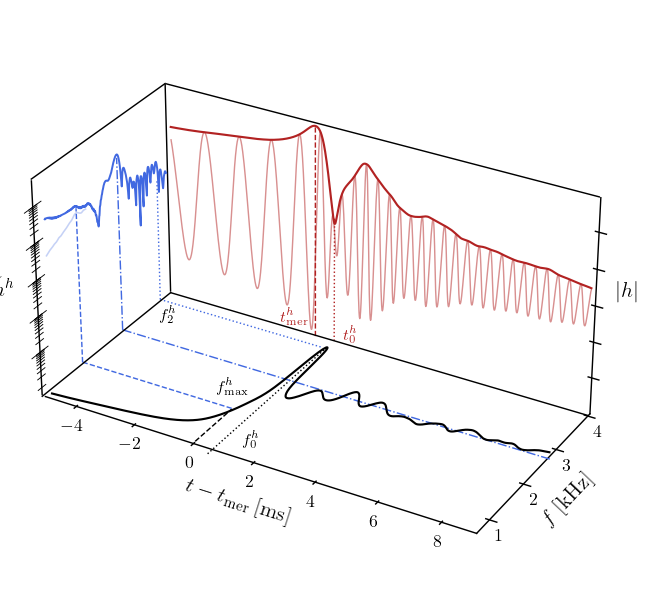

In [13]:

NAME="BAM:0012"

polarization="both"

interpolation="resample"

filtering="none"
#filtering="savgol"

smoothing_at_the_end=False

savgol_window_order=3
savgol_window_size=11


xmin=-5
xmax=9
ymin=0.5
ymax=4
zmin=0
zmax=12-0.2

#psi4_22=psi_ts22[NAME]
CU = UC.geom_umass_msun(1)
strain_22=strain_ts22[NAME]

f_interp, psd_22, psd_22_sub =return_psd_only22(strain_22,
                                                             polarization,
                                                             interpolation,
                                                             filtering,
                                                             savgol_window_size,
                                                             savgol_window_order,
                                                             smoothing_at_the_end) 

fig = plt.figure(figsize=(6,6), dpi=128)
ax = fig.add_subplot(projection='3d', computed_zorder=False)
mpl.rcParams.update({"axes.grid" : True, "grid.color": "gray"})


psd_22_sub_full=FrequencySeries(f_interp,psd_22_sub)
psd_22_full_full=FrequencySeries(f_interp,psd_22)


psd_22_inv=FrequencySeries(psd_22_sub_full.f, 1e-21-psd_22_sub_full.fft).copy()

psd_22_inv_full=FrequencySeries(psd_22_full_full.f, 1e-20-psd_22_full_full.fft).copy()


fpoints=np.where((f_interp>ymin+0.4) & (f_interp<4))
ax.plot(f_interp[fpoints], 2*np.log10(7e27*psd_22[fpoints])-3, zs=xmin-0.2, zdir='x',zorder=10,
       linewidth=1.1, 
       color='royalblue')

fpoints=np.where((f_interp>ymin+0.4) & (f_interp<ymin+1.4))
ax.plot(f_interp[fpoints], 2*np.log10(7e27*psd_22_sub[fpoints])-3, zs=xmin-0.2, zdir='x',zorder=10,
       linewidth=0.9, 
       color='royalblue', alpha=0.3, linestyle='solid' )
#print(np.log10(psd_22)

indx_trunc=np.where(f_interp>1.5)
ftrunc=f_interp[indx_trunc]
psd_22_trunc=psd_22[indx_trunc]
indx_fmax=np.argmax(psd_22_trunc)
f2_freq=ftrunc[indx_fmax]
psd_val_at_f2_freq=1.5*np.log10(1e27*psd_22[indx_fmax])-0.5


######################################
### HERE 
######################################
CU = UC.geom_umass_msun(1)
STRAIN22=strain_ts22[NAME].copy()
fgw = STRAIN22.phase_frequency().abs() #time in [s]

PSI4_22=psi_ts22[NAME].copy()
fgw_psi4 = PSI4_22.phase_frequency().abs() #time in [s]

dt=2./1000 # X/1000, where X in ms
windN=int(dt/(STRAIN22.t[1]-STRAIN22.t[0]))

if(windN%2==0):
    windN+=1
print(windN)

import scipy.interpolate
from scipy.interpolate import interp1d as i1d

amp_strain=TimeSeries(strain_22.t,np.sqrt(strain_22.y.imag**2 + strain_22.y.real**2))
tmer_strain=strain_22.x_at_abs_maximum_y()
tmer=tmer_strain*1000
print("tmer_strain:", tmer)


tpoints=np.where((amp_strain.t*1000-tmer>xmin) & (amp_strain.t*1000-tmer<xmax))
ax.plot(amp_strain.t[tpoints]*1000 - tmer, 3.3*amp_strain.y[tpoints]+6, zs=ymax, 
        color='firebrick', zdir='y', zorder=10,
       linewidth=1.2)#, label='curve in (x, y)')

ax.plot(amp_strain.t[tpoints]*1000 - tmer, 3.3*strain_22.y[tpoints]+6, zs=ymax, 
        color='firebrick', zdir='y', zorder=10,
       linewidth=0.8,alpha=0.5)#, label='curve in (x, y)')

fgw_interp_psi4=i1d(1000 * fgw_psi4.t,fgw_psi4.y/1000)


phase=STRAIN22.unfolded_phase()

from scipy.misc import derivative as scp_der
phase_interp=i1d(phase.t, phase.y)
PSI4_22=psi_ts22[NAME].copy()
CU = UC.geom_umass_msun(1)
PSI4_22=PSI4_22.time_unit_changed(CU.time, inverse=True).copy()
fgw_psi4 = PSI4_22.phase_frequency().abs() #time in [s]
fgw_psi4.savgol_smooth(10,1)

tt=np.linspace(phase.t[20], phase.t[-20],1000)


val=2.45
ax.set_box_aspect(aspect = (4,2,2))

ax.set_xlim(xmin,xmax)
ax.set_ylim(ymin,ymax)
ax.set_zlim(zmin,zmax)
fgw.savgol_smooth(20,1)

tpoints=np.where((fgw.t*1000 - tmer>xmin) & (fgw.t*1000 - tmer<xmax))
ax.plot(fgw.t[tpoints]*1000 - tmer, fgw.y[tpoints]/1000, zs=0., zdir='z',
        color='black', zorder=10, linewidth=1.2)

f_interp_local=list(f_interp)
f_interp_local+=[f_interp[-1]+i*0.1 for i in range(70)]
f_interp_local=np.array(f_interp_local)
f_interp_local=f_interp[280:-2100]
ax.plot(0*np.ones_like(f_interp_local),f_interp_local, zs=0, zdir='z', color='black', alpha=1.0, linewidth=0.8,linestyle='dashed')

f_interp_local=f_interp[200:-1200]
ax.plot(0.65*np.ones_like(f_interp_local),f_interp_local, zs=0, zdir='z', color='black', alpha=1.0, linewidth=0.8,linestyle='dotted')

z_local=np.linspace(-0.05,11.8,100)
#ax.plot(0*np.ones_like(z_local),z_local, zs=ymax+0.15, zdir='y', color='firebrick', alpha=1.0, linewidth=0.8, linestyle='dashed')#, label=r"$f_{\rm{max}}$")
ax.plot(0*np.ones_like(z_local),z_local, zs=ymax, zdir='y', color='firebrick', alpha=1.0, linewidth=0.8, linestyle='dashed')#, label=r"$f_{\rm{max}}$")

z_local=np.linspace(0,7.,100)
#ax.plot(0.6*np.ones_like(z_local),z_local, zs=ymax+0.1, zdir='y', color='purple', alpha=1.0, linewidth=0.8, linestyle='dashed')#, label=r"$f_{\rm{max}}$")
ax.plot(0.65*np.ones_like(z_local),z_local, zs=ymax, zdir='y', color='firebrick', alpha=1.0, linewidth=0.8, linestyle='dotted')#, label=r"$f_{\rm{max}}$")
#print(tmer, "tmer")
#print(fgw_psi4.t * 1000)
tpoint_mer=np.argmax(fgw_psi4.t*1000-tmer>0)
#print(fgw_psi4.y[tpoint_mer])
fgw_mer=fgw_psi4.y[tpoint_mer]


z_local=np.linspace(0,9.8,100)
ax.plot(f2_freq*np.ones_like(z_local),z_local, zs=xmin-0.2, zdir='x', color='royalblue',alpha=1.0, linewidth=0.8, linestyle='dashdot')

t_local_line=np.linspace(xmin-0.2,xmax+0.2,100)
ax.plot(t_local_line, f2_freq*np.ones_like(t_local_line), 
        color='royalblue', alpha=1.0, zs=0., zdir='z',  linewidth=0.8, linestyle='dashdot')#, label='curve in (x, y)')


z_local=np.linspace(0,7.0,100)
ax.plot(3.75*np.ones_like(z_local),z_local, zs=xmin-0.2, zdir='x', color='royalblue',
        alpha=1.0, linewidth=0.8, linestyle='dotted')
t_local_line=np.linspace(xmin-0.2, 0.55,100)
ax.plot(t_local_line, 3.75*np.ones_like(t_local_line), 
    color='royalblue', alpha=1.0, zs=0., zdir='z',  linewidth=0.8, linestyle='dotted')#, label='curve in (x, y)')

z_local=np.linspace(0,8.7,100)
ax.plot(fgw_mer/1000*np.ones_like(z_local),z_local, zs=xmin-0.2, zdir='x', color='royalblue',
        alpha=1.0, linewidth=0.8, linestyle='dashed')
t_local_line=np.linspace(xmin-0.2,0.0,100)
ax.plot(t_local_line, fgw_mer/1000*np.ones_like(t_local_line), 
    color='royalblue', alpha=1.0, zs=0., zdir='z',  linewidth=0.8, linestyle='dashed')#, label='curve in (x, y)')

ax.plot([],[],color='red', marker='*', label=r"$f_{\rm{mer}}^{\Psi_{4}}$")
ax.plot([],[],color='orange', marker='o', label=r"$f_{2}^{\Psi_{4}}$")
ax.plot([],[],color='purple', marker='s', label=r"$f_{0}^{\Psi_{4}}$")

ax.axes.set_xlim3d(left=xmin+0.2, right=xmax-0.2) 
ax.axes.set_ylim3d(bottom=ymin+0.2, top=ymax-0.2) 
ax.axes.set_zlim3d(bottom=zmin+0.2, top=zmax-0.2) 

ax.view_init(30, -60)

ax.set_xlabel(r"$t-t_{\rm{mer}} \; [\rm{ms}]$", fontsize=12,labelpad=-1)
ax.set_ylabel(r"$f \; [\rm{kHz}]$", fontsize=12, labelpad=-8)
c1=0.2
c2=0.2
c3=0.2
c4=0.0


ax.w_xaxis.set_pane_color((c1, c2, c3, c4))
ax.w_yaxis.set_pane_color((c1, c2, c3, c4))
ax.w_zaxis.set_pane_color((c1, c2, c3, c4))

[t.set_color('black') for t in ax.xaxis.get_ticklines()]
[t.set_color('black') for t in ax.xaxis.get_ticklabels()]

psd_name=r"$2 \sqrt{f} \tilde{h}^{h}$"
ax.text(-5.6,-1,8.2,psd_name, fontsize=12)#, zdir='y' )

amp_name=r"$\vert h \vert$"
ax.text(9.8,4,7,amp_name, fontsize=12)#, zdir='x' )

ax.set_zticklabels([])

ax.grid(False)

x_line=np.linspace(xmin-0.15,xmax+0.1,100)
ax.plot(x_line, ymax*np.ones_like(x_line), 
        color='black', zs=0., zdir='z',  linewidth=0.8)#, label='curve in (x, y)')
x_line=np.linspace(xmin-0.1,xmax+0.1,1000)
ax.plot(x_line, ymax*np.ones_like(x_line), 
        color='black', zs=12, zdir='z',  linewidth=0.8)#, label='curve in (x, y)')

y_line=np.linspace(ymin+0.1,ymax,100)
ax.plot((xmin-0.15)*np.ones_like(y_line),y_line, 
        color='black', zs=0, zdir='z',  linewidth=0.8)#, label='curve in (x, y)')
ax.plot((xmin-0.15)*np.ones_like(y_line),y_line, 
        color='black', zs=12, zdir='z',  linewidth=0.8)#, label='curve in (x, y)')


z_line=np.linspace(zmin+0.1,zmax+0.15,100)
ax.plot((xmin-0.15)*np.ones_like(z_line),z_line, 
        color='black', zs=ymax, zdir='y',  linewidth=0.8)#, label='curve in (x, y)')
z_line=np.linspace(zmin+0.1,zmax+0.1,100)
ax.plot((xmin-0.15)*np.ones_like(z_line),z_line, 
        color='black', zs=0.6, zdir='y',  linewidth=0.8) # along this have to be ticks


z_log_tick_locs=[2*(j+np.log10(i*0.1)) for i in range(1,11) for j in range(1,6)]
y_line=np.linspace(ymin+0.01,ymin+0.2,10)
z_0=0.5
for z_pos in z_log_tick_locs:
    ax.plot((xmin-0.15)*np.ones_like(y_line),y_line, 
        color='black', zs=z_0+z_pos, zdir='z',  linewidth=0.5)#
z_log_tick_locs=[2*j for j in range(1,6)]
z_0=0.5
y_line=np.linspace(ymin-0.1,ymin+0.3,10)
for z_pos in z_log_tick_locs:
    ax.plot((xmin-0.15)*np.ones_like(y_line),y_line, 
        color='black', zs=z_0+z_pos, zdir='z',  linewidth=0.5)#

fmer_name=r"$f^{h}_{\rm{max}}$"
ax.text(-0.2,1.4,1.4,fmer_name, fontsize=9, color='black', zorder=10)#, zdir='x' )

f2_name=r"$f^{h}_{2}$"
ax.text(-4.6,3.25,0,f2_name, fontsize=9, color='black')#, zdir='x' )

f0_name=r"$f^{h}_{0}$"
ax.text(1.9,0.4,1.4,f0_name, fontsize=9, color='black')#, zdir='x' )

t0_name=r"$t_{0}^{h}$"
ax.text(1.2,3.8,0.7,t0_name, fontsize=9, color='firebrick')#, zdir='x' )
tmer_name=r"$t_{\rm{mer}}^{h}$"
ax.text(-1.,3.8,0.7,tmer_name, fontsize=9, color='firebrick')#, zdir='x' )


ax.set_yticks([1,2,3,4])
ax.set_yticklabels(["1", "2", "3", "4"])
ax.tick_params(axis='y', which='major', pad=-4)

ax.tick_params(axis='x', which='major', pad=-2,)


plt.tight_layout()
plt.savefig('../doc/figs/Fig1_h.pdf')

plt.show()

plt.close()

